In [45]:
# import Pkg
using JuMP
using Printf
using Convex
using Gurobi
using LinearAlgebra
using Random
using SparseArrays
using Plots
using Ipopt
using JLD
using LIBSVM

include("proximal_bundle_method_main/src/solver.jl")
include("proximal_bundle_method_main/src/data_cleaning.jl")
include("proximal_bundle_method_main/src/PBA_utils.jl")
include("proximal_bundle_method_main/src/output_utils.jl")
include("proximal_bundle_method_main/src/computations_utils.jl")

get_sliding_min (generic function with 1 method)

In [18]:
Random.seed!(2625)
# instance_names = ["colon-cancer", "duke", "leu", "ijcnn1", "skin_nonskin", "gisette_scale", "covtype"]
name = "duke"
instance_names = [name]
instances_ = Dict()
for name in instance_names
    instances_[name] = preprocess_learning_data(load_libsvm_file("proximal_bundle_method_main/data/" * name))
    samples, features  = size(instances_[name].feature_matrix)
    println(name* " --- number of features = "*string(features)*" || number of samples = "*string(samples))
end

duke --- number of features = 7130 || number of samples = 44


In [19]:
max_nb_samples = 100000#Inf
instance = instances_[name]
Xp = (instance.feature_matrix)
y = instance.labels
try
    nb_samples = min(max_nb_samples, size(Xp, 1))

    indices = randperm(size(Xp, 1))[1:nb_samples]
    Xp = Xp[indices, :]
    y = y[indices]
catch
    # Handle any potential errors
end

n, m = size(Xp)

x_init = randn(m) / m
coefficients = [0.01/n]
coeff = coefficients[1]
print("\n------------------------------------\n")
Printf.@printf("Instance %s, coeff %12g\n", name, coeff)
println("Solving with Convex.jl first")
opt_val = compute_minimum_with_jump(Xp, y, coeff)
Printf.@printf("Obj=%12g\n", opt_val,)


------------------------------------
Instance duke, coeff  0.000227273
Solving with Convex.jl first
Set parameter TokenServer to value "flexlm"
Set parameter BarConvTol to value 1e-10
Set parameter BarQCPConvTol to value 1e-10
Set parameter BarQCPConvTol to value 1e-10
Set parameter BarConvTol to value 1e-10
Gurobi Optimizer version 10.0.0 build v10.0.0rc2 (linux64)

CPU model: Intel(R) Xeon(R) Platinum 8260 CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 48 physical cores, 96 logical processors, using up to 32 threads

Optimize a model with 44 rows, 7174 columns and 313764 nonzeros
Model fingerprint: 0xe0a68d7d
Model has 7130 quadratic objective terms
Coefficient statistics:
  Matrix range     [3e-07, 1e+00]
  Objective range  [2e-02, 2e-02]
  QObjective range [2e-04, 2e-04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve time: 0.05s
Presolved: 44 rows, 7174 columns, 313764 nonzeros
Presolved model has 7130 quadratic objective terms
Or

## Params

In [20]:
eps_optimal = 1e-5
timeout = 300
verbose =  false


iteration_limit = 100000
printing_frequency = 10
full_function = true
objective = (w -> svm_objective(w, Xp, y, coeff, full_function) - opt_val)
gradient = (w -> svm_subgradient(w, Xp, y, coeff,full_function))

#Pegasos
batch_size = Int(floor(size(Xp)[1]/10))
# batch_size = 5

# eps_optimal = 1e-4
epsilon = eps_optimal
delta = eps_optimal/2
rho = 1e-2/size(Xp)[1]

manage_bundle_values = [Keep_active, Keep_all, Keep_active_null_step];

## RUN

In [21]:
(obj, maxpasses, list_obj_value_gap_pegasos, list_times_pegasos,list_iter_index_pegasos, w, has_timeout_pegasos) = pegasos(
    Xp, y,opt_val, x_init, batch_size, coeff, Int(floor(iteration_limit * size(Xp)[1]/batch_size)), printing_frequency, eps_optimal, verbose, timeout);

In [22]:
params_subgradient = SubgradientMethodParams(
        eps_optimal,
        iteration_limit,
        verbose,
        printing_frequency,
        timeout
    )
poly_step_size = ((_, _, t) -> 1 / (coeff * t))
sol_subgradient = solve(
                objective,
                gradient,
                params_subgradient,
                poly_step_size,
                x_init,);

In [23]:
full_function = false
objective = (w -> svm_objective(w, Xp, y, coeff, full_function) - opt_val)
gradient = (w -> svm_subgradient(w, Xp, y, coeff,full_function))

#87 (generic function with 1 method)

In [24]:
manage_bundle_values = [Keep_active, Keep_all]
# for rho in [1e-6, 1e-4, 1e-2, 1, 1e2, 1e4, 1e6]./size(Xp)[1]
#     println("---------------")
#     print("rho = ", rho)
    goal_obj = 0.
    dic_gaps = Dict()
    dic_times = Dict()
    dic_bundle_size = Dict()
    dic_has_timeout_bundle = Dict()
    dic_runtimes_bundle = Dict()
    # Plot the bundle sizes for each value of manage_bundle
    for manage_bundle in manage_bundle_values
        println(manage_bundle)
        flush(stdout)
        dict_cut,master_model, list_number_null_steps, number_serious_steps, bundle_size,runtime, list_obj_value_gap, list_times, has_timeout_bundle = solve_PBA(x_init,rho,epsilon,delta, manage_bundle, goal_obj,coeff,Xp, y,opt_val,  verbose, timeout)
        println(manage_bundle, " -- Runtime : ", runtime) 
        dic_bundle_size[manage_bundle] = bundle_size
        dic_gaps[manage_bundle] = list_obj_value_gap .- goal_obj
        dic_times[manage_bundle] = list_times
        dic_has_timeout_bundle[manage_bundle] = has_timeout_bundle
        dic_runtimes_bundle[manage_bundle] = runtime
    end
# end

Keep_active
Set parameter TokenServer to value "flexlm"
Set parameter FeasibilityTol to value 1e-08
Number of iterations : 162
Keep_active -- Runtime : 60.321988105773926
Keep_all
Set parameter TokenServer to value "flexlm"
Set parameter FeasibilityTol to value 1e-08
Number of iterations : 100
Keep_all -- Runtime : 45.251883029937744


## Plots

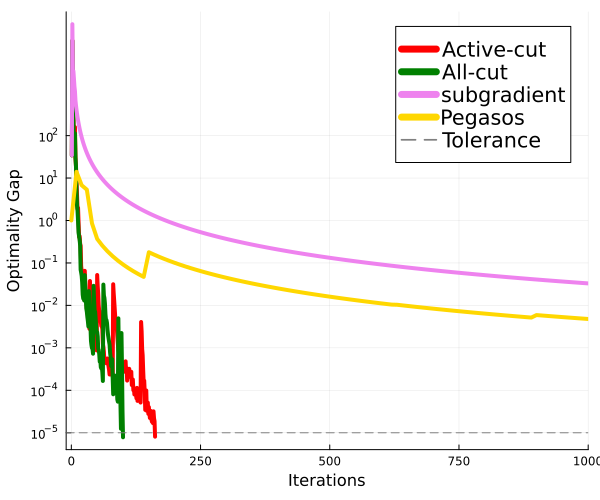

In [25]:
p = plot(size = (600,500))
for manage_bundle in manage_bundle_values
    # plot!(dic_gaps[manage_bundle], label = "", color = color_dic[manage_bundle],linewidth=4)
    plot!(dic_gaps[manage_bundle], label = dic_names_method[manage_bundle], color = color_dic[manage_bundle],linewidth=4)
end
plot!([s.objective for s in sol_subgradient.iteration_stats], label = "subgradient", linewidth = 4, color = "violet")
plot!(list_iter_index_pegasos, list_obj_value_gap_pegasos, label = "Pegasos", linewidth = 4; color = "gold")

hline!([eps_optimal], linestyle=:dash, label="Tolerance", color = "grey")
xlabel!("Iterations")
ylabel!("Optimality Gap")
plot!(legendfontsize=14)
# y_ticks = range(1e-4, stop=1e1, length=20)
# title!("Progress for different bundle management strategies")
plot!(yaxis=:log, yticks = [1e-5, 1e-4, 1e-3, 1e-2,1e-1, 1, 10, 100])
# ylims!(1e-5, 100)
xlims!(-10, 1000)
# savefig(p, "Optimality_gap.pdf") 
# savefig(p, "proximal_bundle_method_main/outputs/Optimality_gap_by_iteration_"*name*"_"*string(coeff)*"_"*string(max_nb_samples)*"_rho_"*string(rho)*".pdf") 
plot!()

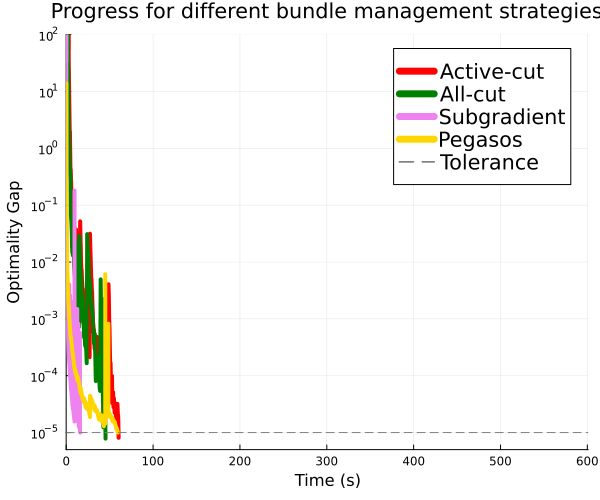

In [26]:
p = plot(size = (600,500))
for manage_bundle in manage_bundle_values
    # plot!(dic_gaps[manage_bundle], label = "", color = color_dic[manage_bundle],linewidth=4)
    plot!(dic_times[manage_bundle],dic_gaps[manage_bundle], label = dic_names_method[manage_bundle], color = color_dic[manage_bundle],linewidth=4)
end
plot!([s.time - sol_subgradient.iteration_stats[1].time for s in sol_subgradient.iteration_stats], ([s.objective for s in sol_subgradient.iteration_stats]), label = "Subgradient", linewidth = 4, color = "violet")
plot!(list_times_pegasos, list_obj_value_gap_pegasos, label = "Pegasos", linewidth = 4, color = "gold")

hline!([eps_optimal], linestyle=:dash, label="Tolerance", color = "grey")
xlabel!("Time (s)")
ylabel!("Optimality Gap")
plot!(legendfontsize=14)
# y_ticks = range(1e-4, stop=1e1, length=20)
title!("Progress for different bundle management strategies")
plot!(yaxis=:log, yticks = [1e-5, 1e-4, 1e-3, 1e-2,1e-1, 1, 10, 100])
ylims!(eps_optimal/2, 100)
xlims!(-0.1, 601)
# savefig(p, "proximal_bundle_method_main/outputs/Optimality_gap_by_time_"*name*"_"*string(max_nb_samples)*".pdf") 

plot!()